
DATASET PREVIEW:

   ANGLE  VELOCITY        Cd
0    0.0        15  0.199399
1   30.0        15  0.254284
2   45.0        15  0.269030
3   60.0        15  0.269722
4   75.0        15  0.231854

COLUMN NAMES:

Index(['ANGLE', 'VELOCITY', 'Cd'], dtype='object')

MODEL TRAINED SUCCESSFULLY!

MODEL PERFORMANCE
--------------------------------
R2 Score = 0.8400300003641724
Mean Absolute Error = 0.10722850713333303


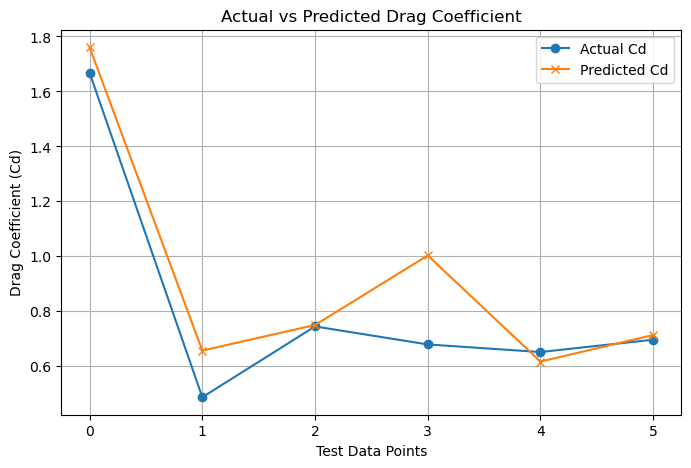


CUSTOM PREDICTION
--------------------------------
Angle = 35 degrees
Velocity = 28 m/s
Predicted Cd = 1.0604461847000015

FEATURE IMPORTANCE
--------------------------------
ANGLE Importance = 0.06693476866457682
VELOCITY Importance = 0.9330652313354231


In [1]:
# ============================================
# CAR DRAG PREDICTION USING RANDOM FOREST
# ============================================

# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ============================================
# LOAD EXCEL DATASET
# ============================================

data = pd.read_excel("car_drag_dataset.xlsx")

# REMOVE EXTRA SPACES FROM COLUMN NAMES
data.columns = data.columns.str.strip()

# DISPLAY DATASET
print("\nDATASET PREVIEW:\n")
print(data.head())

# DISPLAY COLUMN NAMES
print("\nCOLUMN NAMES:\n")
print(data.columns)

# ============================================
# INPUT FEATURES AND OUTPUT
# ============================================

# INPUT PARAMETERS
X = data[['ANGLE', 'VELOCITY']]

# OUTPUT PARAMETER
y = data['Cd']

# ============================================
# SPLIT DATASET
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# CREATE RANDOM FOREST MODEL
# ============================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# ============================================
# TRAIN MODEL
# ============================================

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY!")

# ============================================
# MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

# ============================================
# MODEL PERFORMANCE
# ============================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("--------------------------------")
print("R2 Score =", r2)
print("Mean Absolute Error =", mae)

# ============================================
# ACTUAL VS PREDICTED GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    y_test.values,
    marker='o',
    label='Actual Cd'
)

plt.plot(
    y_pred,
    marker='x',
    label='Predicted Cd'
)

plt.xlabel("Test Data Points")
plt.ylabel("Drag Coefficient (Cd)")
plt.title("Actual vs Predicted Drag Coefficient")

plt.legend()
plt.grid()

plt.show()

# ============================================
# CUSTOM PREDICTION
# ============================================

angle = 35
velocity = 28

new_data = pd.DataFrame({
    'ANGLE': [angle],
    'VELOCITY': [velocity]
})

prediction = model.predict(new_data)

print("\nCUSTOM PREDICTION")
print("--------------------------------")
print("Angle =", angle, "degrees")
print("Velocity =", velocity, "m/s")
print("Predicted Cd =", prediction[0])

# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = model.feature_importances_

print("\nFEATURE IMPORTANCE")
print("--------------------------------")
print("ANGLE Importance =", importance[0])
print("VELOCITY Importance =", importance[1])

In [2]:
# ============================================
# OPTIMIZATION OF DRAG COEFFICIENT
# ============================================

import numpy as np
import pandas as pd

# Create ranges for angle and velocity
angles = np.arange(0, 91, 1)        # 0° to 90°
velocities = np.arange(10, 41, 1)   # 10 to 40 m/s

# Store results
results = []

# Predict Cd for every combination
for angle in angles:
    for velocity in velocities:

        input_data = pd.DataFrame({
            'ANGLE': [angle],
            'VELOCITY': [velocity]
        })

        predicted_cd = model.predict(input_data)[0]

        results.append([angle, velocity, predicted_cd])

# Convert into dataframe
results_df = pd.DataFrame(
    results,
    columns=['ANGLE', 'VELOCITY', 'PREDICTED_CD']
)

# Find minimum Cd
best_result = results_df.loc[
    results_df['PREDICTED_CD'].idxmin()
]

# Display optimum condition
print("\nOPTIMIZATION RESULT")
print("--------------------------------")

print("Best Angle =", best_result['ANGLE'], "degrees")
print("Best Velocity =", best_result['VELOCITY'], "m/s")
print("Minimum Predicted Cd =", best_result['PREDICTED_CD'])


OPTIMIZATION RESULT
--------------------------------
Best Angle = 83.0 degrees
Best Velocity = 10.0 m/s
Minimum Predicted Cd = 0.20208114030000002


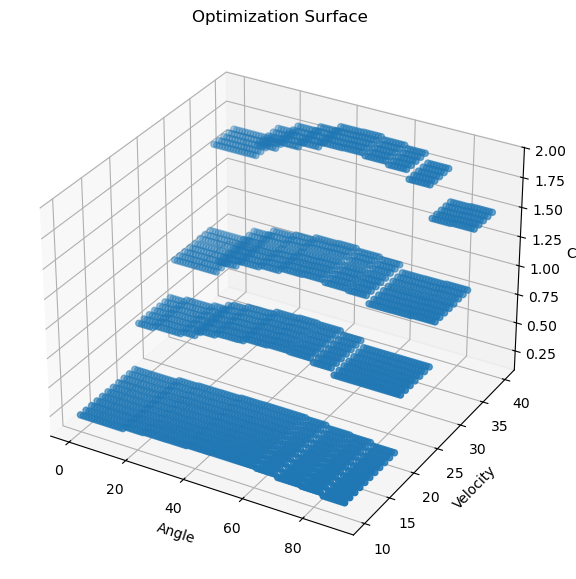

In [3]:
# ============================================
# 3D SURFACE PLOT
# ============================================

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    results_df['ANGLE'],
    results_df['VELOCITY'],
    results_df['PREDICTED_CD']
)

ax.set_xlabel('Angle')
ax.set_ylabel('Velocity')
ax.set_zlabel('Cd')

plt.title("Optimization Surface")
plt.show()

In [4]:
# USER INPUT

angle = float(input("Enter Angle: "))
velocity = float(input("Enter Velocity: "))

# CREATE INPUT DATAFRAME
new_data = pd.DataFrame({
    'ANGLE': [angle],
    'VELOCITY': [velocity]
})

# PREDICT Cd
predicted_cd = model.predict(new_data)[0]

# DISPLAY RESULT
print("\nPREDICTED RESULT")
print("----------------------")
print("Angle =", angle)
print("Velocity =", velocity)
print("Predicted Cd =", predicted_cd)

Enter Angle:  22
Enter Velocity:  18



PREDICTED RESULT
----------------------
Angle = 22.0
Velocity = 18.0
Predicted Cd = 0.24919381139999974
